# 1) Load Data and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, f1_score

import cupy as cp
import cudf
from cuml.preprocessing import StandardScaler
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.metrics import accuracy_score

import xgboost as xgb

In [2]:
df = pd.read_csv("sample_to_run_info.csv")

/tmp/ipykernel_1226/2515147133.py:1: DtypeWarning: Columns (22,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sample_to_run_info.csv")


In [3]:
abundance = pd.read_csv('species_abundance.csv')

# 2) Exploratory Data Analysis & Cleaning

### Work with the Sample to Run Info (df)

In [4]:
# Get rid of all features that have more than 50% of their data missing
thresh = int(len(df) * 0.5)
df = df.dropna(axis=1, thresh=thresh)

In [5]:
# Sneak peek at data
df.head()

,project_id,sample_name,original_sample_description,run_id,sample_id,second_sample_id,experiment_type,nr_reads_sequenced,instrument_model,disease,phenotype,more,country,collection_date,longitude,latitude
0,PRJDB3418,NaN,APr10S00,DRR028772,DRS020620,SAMD00024580,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
1,PRJDB3418,NaN,APr14S00,DRR028773,DRS020607,SAMD00024581,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
2,PRJDB3418,NaN,APr15S00,DRR028774,DRS020582,SAMD00024582,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
3,PRJDB3418,NaN,APr21S00,DRR028775,DRS020613,SAMD00024583,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
4,PRJDB3418,NaN,APr24S00,DRR028776,DRS020600,SAMD00024584,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN


In [6]:
# Removed what is determined to be unnecessary
df = df.drop(['more', 'collection_date', 'longitude', 'latitude', 'sample_name', 'original_sample_description', 'sample_id', 'second_sample_id', 'disease'], axis=1)

In [7]:
df.head()

,project_id,run_id,experiment_type,nr_reads_sequenced,instrument_model,phenotype,country
0,PRJDB3418,DRR028772,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
1,PRJDB3418,DRR028773,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
2,PRJDB3418,DRR028774,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
3,PRJDB3418,DRR028775,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
4,PRJDB3418,DRR028776,AMPLICON,3000.0,454 GS FLX,Healthy,Japan


In [8]:
df['phenotype'].value_counts()

,count
phenotype,
Healthy,48241
Colorectal Neoplasms,5543
Crohn Disease,3516
COVID-19,2911
Parkinson Disease,2169
...,...
Colonic Polyps,5
Urolithiasis,5
Dry Eye Syndromes,4


In [9]:
# The phenotypes we will be keeping
keep_phenos = [
    "Healthy",
    "Crohn Disease",
    "Colitis, Ulcerative",
]

df = df[df["phenotype"].isin(keep_phenos)].copy()
print(df["phenotype"].value_counts())

phenotype
Healthy                48241
Crohn Disease           3516
Colitis, Ulcerative     1863
Name: count, dtype: int64


In [10]:
# A stricter filter to keep only the projects which are mainly associated with these phenotypes (Crohn's, UC, and only the healthy patients in projects that collected those two diseases).
target_phenotypes = ["Crohn Disease", "Colitis, Ulcerative"]

project_ids = (
    df[df["phenotype"].isin(target_phenotypes)]["project_id"]
    .unique()
)

df = df[df["project_id"].isin(project_ids)].copy()

print(f"Projects with at least one Crohn Disease or Ulcerative Colitis sample: {len(project_ids)}")
print(df["phenotype"].value_counts())

Projects with at least one Crohn Disease or Ulcerative Colitis sample: 46
phenotype
Crohn Disease          3516
Healthy                2099
Colitis, Ulcerative    1863
Name: count, dtype: int64


In [11]:
df['country'].value_counts()

,count
country,
United States of America,3698
China,970
Canada,666
Sweden,637
South Korea,263
Japan,196
Russia,168
Germany,167
India,101


In [ ]:
df['experiment_type'].value_counts()

# Amplicon Sequencing is a method that targets and copies specific pieces of DNA
# (amplicons) via PCR to quickly identify which microbes are present in a sample.

# Metagenomic Sequencing is a method that sequences all genetic material directly
# extracted from environmental samples to study the entire microbial community and its functions.

print(pd.crosstab(df['phenotype'], df['experiment_type'], normalize='index'))

# NOTE: this is the pre-merge picture. The species-abundance merge later (cell 23)
# drops almost all AMPLICON samples, so the modelling data is effectively
# shotgun/metagenomics only — see the experiment_type check on `merged` below.

In [ ]:
# Check whether any single phenotype is confined to (or dominated by) one sequencing
# platform, which would confound platform effects with disease signal. Only Healthy,
# Crohn, and UC remain here after the cell-11 filter; all three appear across the
# major Illumina platforms, so no phenotype is tied to a single instrument.
ct_counts = pd.crosstab(df['phenotype'], df['instrument_model'])
ct_counts

### Work with the Species Abundance (abundance)

In [14]:
abundance.head()

,id,loaded_uid,ncbi_taxon_id,taxon_rank_level,relative_abundance,accession_id
0,1,81104,-1,genus,1.95190,DRR358335
1,2,81104,544,genus,1.07457,DRR358335
2,3,81104,561,genus,0.84957,DRR358335
3,4,81104,570,genus,0.06218,DRR358335
4,5,81104,816,genus,23.29699,DRR358335


In [15]:
abundance['taxon_rank_level'].value_counts()

,count
taxon_rank_level,
genus,2780064
species,2761207


In [16]:
# Keep only species level because it is more specific than genus, allowing us to
# better pinpoint bacteria types and reasoning
abund_species = abundance[abundance["taxon_rank_level"] == "species"].copy()

# Drop rows with ncbi_taxon_id = -1 (unassigned/other)
abund_species = abund_species[abund_species["ncbi_taxon_id"] != -1].copy()

In [17]:
# We take bacteria names and make them columns, and if they exist, their values
# are relative abundances

# Pivot: run_id x ncbi_taxon_id, values = relative_abundance
abund_wide = (
    abund_species
    .pivot_table(index="accession_id",      # this matches run_id in df
                 columns="ncbi_taxon_id",
                 values="relative_abundance",
                 aggfunc="sum",
                 fill_value=0.0)
    .reset_index()
)

# Make column names nicer (e.g., taxon_544, taxon_561, ...)
abund_wide.columns = [
    "run_id" if c == "accession_id" else f"taxon_{int(c)}"
    for c in abund_wide.columns
]

### Merge the data

In [18]:
merged = df.merge(abund_wide, on="run_id", how="inner")

In [19]:
# There was 46 batches before and now there are 12
matched = df.run_id.isin(abund_wide.run_id)
missing = df[~matched]                      # ~ inverts the boolean mask
print("dropped:", len(missing))
print(missing.experiment_type.value_counts())
print(missing.phenotype.value_counts())
print("projects before:", df.project_id.nunique(), "| after:", merged.project_id.nunique())

dropped: 4640
experiment_type
AMPLICON        4444
Metagenomics     196
Name: count, dtype: int64
phenotype
Crohn Disease          2202
Healthy                1366
Colitis, Ulcerative    1072
Name: count, dtype: int64
projects before: 46 | after: 12


In [20]:
merged.head()

,project_id,run_id,experiment_type,nr_reads_sequenced,instrument_model,phenotype,country,taxon_9,taxon_17,taxon_69,...,taxon_2968459,taxon_2968968,taxon_2969304,taxon_2972461,taxon_2972466,taxon_2972769,taxon_2974552,taxon_2974597,taxon_2975484,taxon_2981769
0,PRJEB76677,ERR13295986,Metagenomics,61317544.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
1,PRJEB76677,ERR13295987,Metagenomics,44948398.0,Illumina HiSeq 2000,Healthy,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.55599
2,PRJEB76677,ERR13295988,Metagenomics,7314392.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
3,PRJEB76677,ERR13295989,Metagenomics,48624378.0,Illumina HiSeq 2000,Healthy,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.45498
4,PRJEB76677,ERR13295990,Metagenomics,61732518.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01691


In [ ]:
# Settle the amplicon question on the data we actually model.
# The inner merge on run_id kept only samples with a species-abundance profile,
# which are overwhelmingly shotgun/metagenomics (nearly all AMPLICON rows were
# dropped, see cell above). So the merge already decided this for us: the modelling
# set is effectively single-technology, and species-level abundances are appropriate.
print(merged.experiment_type.value_counts())

In [21]:
# The following features, after EDA, aren't relevant
META_COLS    = ["project_id", "run_id", "phenotype", "experiment_type",
                "instrument_model", "country", "nr_reads_sequenced"]
FEATURE_COLS = [c for c in merged.columns if c.startswith("taxon_")]

# 3) Labels, Split Diagnostic, & Cross-Validation Setup

In this section we:
1. Create labels for the three phenotypes (Healthy=0, Crohn=1, UC=2)
2. **Show why a single split is untrustworthy**: with only 12 projects a grouped
   hold-out leaves just 2-3 whole cohorts in test, so every downstream metric is
   one unlucky draw.
3. Replace it with **StratifiedGroupKFold (5 folds)** — whole projects stay
   together (no cohort leakage) while labels stay balanced across folds. Every
   sample is tested exactly once, so we report **mean ± std** instead of a single
   number.

Feature selection, model training, XGBoost early stopping, and threshold tuning
all happen **inside each fold** on training/validation data only — the held-out
fold is touched once, for scoring.

In [ ]:
keep_phenos = ["Healthy", "Crohn Disease", "Colitis, Ulcerative"]
# reset_index so positional (iloc) indices from the CV splitter line up with the frame
df3 = merged[merged["phenotype"].isin(keep_phenos)].copy().reset_index(drop=True)

# We label them to 0, 1, and 2 for multiclass labelling
label_map = {
    "Healthy": 0,
    "Crohn Disease": 1,
    "Colitis, Ulcerative": 2,
}
df3["label"] = df3["phenotype"].map(label_map)

taxon_cols = [c for c in df3.columns if c.startswith("taxon_")]
print("samples:", len(df3), "| taxa:", len(taxon_cols), "| projects:", df3.project_id.nunique())

In [ ]:
# Item 2 — confirm how thin a single grouped split really is, BEFORE trusting it.
# With ~12 projects, one 80/20 grouped hold-out puts only 2-3 whole cohorts in test.
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df3, df3["label"], groups=df3["project_id"]))
df_train, df_test = df3.iloc[train_idx], df3.iloc[test_idx]

print(df_train.project_id.nunique(), "train |", df_test.project_id.nunique(), "test")
print(df_test.label.value_counts())   # raw counts, not proportions: how few samples decide each metric

In [ ]:
# Cross-validation setup — this replaces the single split above.
# StratifiedGroupKFold keeps whole projects together (no cohort leakage) while
# balancing labels across folds, so every sample is tested exactly once.
from sklearn.model_selection import StratifiedGroupKFold

groups = df3["project_id"].to_numpy()
y_all  = df3["label"].to_numpy()

N_SPLITS = 5
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Show the fold geometry so the thin per-fold test sets are visible up front.
for f, (tr, te) in enumerate(sgkf.split(df3, y_all, groups)):
    counts = pd.Series(y_all[te]).value_counts().sort_index().to_dict()
    print(f"fold {f}: {len(tr):4d} train / {len(te):3d} test | "
          f"test projects={df3.iloc[te].project_id.nunique()} | test label counts={counts}")


def grouped_val_split(train_idx, y, grp, val_frac=0.25, seed=42):
    """Carve a group-disjoint validation set out of a fold's training indices.

    Used for XGBoost early stopping and threshold tuning so the held-out test
    fold is never consulted during training/tuning.
    """
    gss_inner = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=seed)
    inner, val = next(gss_inner.split(train_idx, y[train_idx], grp[train_idx]))
    return train_idx[inner], train_idx[val]

# 4) Per-Fold L1 Feature Selection (LASSO)

An L1-regularized logistic regression selects a sparse taxa set. Crucially this is
now defined as a helper that is **refit inside every CV fold on that fold's training
cohorts only** — the union of non-zero coefficients across classes becomes the
feature set for that fold, so the held-out projects never influence which features
are chosen.

In [ ]:
def select_features(X_tr_pd, y_tr, C=0.1):
    """Fit L1 multinomial logreg on training rows; return taxa with any non-zero coef.

    X_tr_pd : 2D numpy array of raw abundances (rows=samples, cols=taxon_cols order)
    y_tr    : integer labels for those rows
    """
    scaler = StandardScaler(with_mean=False)
    X_tr_scaled = scaler.fit_transform(cudf.DataFrame(X_tr_pd, columns=taxon_cols))

    clf = cuLogisticRegression(
        penalty="l1",
        C=C,                   # controls sparsity
        l1_ratio=None,         # pure L1
        fit_intercept=True,
        class_weight="balanced",
        max_iter=5000,
        solver="qn",
        verbose=0,
    )
    clf.fit(X_tr_scaled, cudf.Series(y_tr))

    coefs = clf.coef_.to_pandas().to_numpy()   # (n_classes, n_features)
    nz_any = (coefs != 0).any(axis=0)          # keep taxa non-zero for any class
    return list(np.array(taxon_cols)[nz_any])

# 5) Cross-Validated Multiclass Evaluation (Random Forest + XGBoost)

One pass over the 5 StratifiedGroupKFold folds. In each fold we:
1. select features with LASSO on the **training cohorts only** (`select_features`),
2. carve a **grouped validation set** out of the training rows (`grouped_val_split`),
3. train Random Forest on the fold's training data,
4. train XGBoost with **early stopping on the validation set** (never the test fold),
5. predict the held-out fold once and store the predictions.

Because the folds are disjoint, stacking the per-fold predictions gives one
**out-of-fold (OOF)** prediction per sample. We report per-fold accuracy/AUC as
**mean ± std**, and also run the whole thing on `log1p`-transformed abundances so we
can compare engineered vs. raw features (item 6).

In [ ]:
def run_multiclass_cv(transform=None, label="raw"):
    """5-fold grouped CV for the 3-class problem.

    transform : optional feature transform applied to abundances, e.g. np.log1p.
    Returns out-of-fold predictions and per-fold metrics.
    """
    n = len(df3)
    oof_pred_rf   = np.full(n, -1)              # RF prediction per sample (filled once)
    oof_pred_xgb  = np.full(n, -1)              # XGB class prediction per sample
    oof_proba_xgb = np.zeros((n, 3))            # XGB class probabilities per sample
    rf_acc, xgb_acc, xgb_auc = [], [], []

    def prep(idx, feats):
        X = df3.iloc[idx][feats].to_numpy()
        return transform(X) if transform is not None else X

    for tr, te in sgkf.split(df3, y_all, groups):
        # (1) feature selection on training cohorts only
        feats = select_features(df3.iloc[tr][taxon_cols].to_numpy(), y_all[tr])

        # (2) grouped validation carve-out for XGBoost early stopping
        inner, val = grouped_val_split(tr, y_all, groups)

        X_tr, X_inner, X_val, X_te = (prep(tr, feats), prep(inner, feats),
                                      prep(val, feats), prep(te, feats))
        y_te = y_all[te]

        # (3) Random Forest — trains on the full fold-train (no early stopping needed)
        rf = cuRF(n_estimators=300, max_depth=20, max_features=1.0,
                  n_bins=16, bootstrap=True, random_state=42)
        rf.fit(cudf.DataFrame(X_tr, columns=feats), cudf.Series(y_all[tr]))
        pred_rf = rf.predict(cudf.DataFrame(X_te, columns=feats)).to_numpy().astype(int)
        oof_pred_rf[te] = pred_rf
        rf_acc.append((pred_rf == y_te).mean())

        # (4) XGBoost — early stop on the grouped validation set, NOT on test
        dtrain = xgb.DMatrix(X_inner, label=y_all[inner])
        dval   = xgb.DMatrix(X_val,   label=y_all[val])
        dtest  = xgb.DMatrix(X_te,    label=y_te)
        params = {
            "objective": "multi:softprob", "num_class": 3,
            "tree_method": "hist", "max_depth": 6, "eta": 0.1,
            "subsample": 0.8, "colsample_bytree": 0.8,
            "eval_metric": "mlogloss", "device": "cuda",
        }
        bst = xgb.train(params, dtrain, num_boost_round=300,
                        evals=[(dval, "val")], early_stopping_rounds=30,
                        verbose_eval=False)

        # (5) predict the held-out fold once
        proba = bst.predict(dtest)
        oof_proba_xgb[te] = proba
        pred_xgb = proba.argmax(axis=1)
        oof_pred_xgb[te] = pred_xgb
        xgb_acc.append((pred_xgb == y_te).mean())
        try:
            xgb_auc.append(roc_auc_score(np.eye(3)[y_te], proba, multi_class="ovr"))
        except ValueError:
            xgb_auc.append(np.nan)   # a class missing from this test fold

    def ms(a):
        return f"{np.nanmean(a):.3f} ± {np.nanstd(a):.3f}"
    print(f"[{label}] RF  accuracy {ms(rf_acc)}")
    print(f"[{label}] XGB accuracy {ms(xgb_acc)} | macro ROC-AUC {ms(xgb_auc)}")

    return {
        "oof_pred_rf": oof_pred_rf, "oof_pred_xgb": oof_pred_xgb,
        "oof_proba_xgb": oof_proba_xgb,
        "rf_acc": rf_acc, "xgb_acc": xgb_acc, "xgb_auc": xgb_auc,
    }

In [ ]:
# Item 6 — feature engineering: compare raw abundances vs a log1p transform.
# Relative-abundance percentages are heavily right-skewed (a few taxa dominate);
# log1p(x) = ln(1 + x) compresses that tail. Same CV, so the fold scores are
# directly comparable.
res_raw   = run_multiclass_cv(transform=None,     label="raw")
res_log1p = run_multiclass_cv(transform=np.log1p, label="log1p")

# Report downstream from the raw run; switch to res_log1p if it wins above.
res = res_raw

In [ ]:
# Out-of-fold report: every sample was predicted exactly once across the 5 folds,
# so this single report summarises all samples without any test leakage.
target_names = ["Healthy", "Crohn", "UC"]

print("Random Forest — out-of-fold")
print(classification_report(y_all, res["oof_pred_rf"], target_names=target_names))

print("XGBoost — out-of-fold")
print(classification_report(y_all, res["oof_pred_xgb"], target_names=target_names))
print("XGBoost macro ROC-AUC (OOF):",
      roc_auc_score(np.eye(3)[y_all], res["oof_proba_xgb"], multi_class="ovr"))

# 6) Feature Importances (interpretation only)

The CV above gives the honest performance estimate. To ask *which taxa matter*, we
refit the pipeline once on **all** samples — feature selection, Random Forest, and
XGBoost — and read off importances. These are for biological interpretation only;
they are **not** a performance number, because no data was held out here.

In [ ]:
# Refit on all data purely to rank features (do NOT read accuracy into this).
all_feats = select_features(df3[taxon_cols].to_numpy(), y_all)
print("Features selected on full data:", len(all_feats))

X_all_sel = df3[all_feats].to_numpy()

rf_full = cuRF(n_estimators=300, max_depth=20, max_features=1.0,
               n_bins=16, bootstrap=True, random_state=42)
rf_full.fit(cudf.DataFrame(X_all_sel, columns=all_feats), cudf.Series(y_all))

dall = xgb.DMatrix(X_all_sel, label=y_all, feature_names=all_feats)
params_full = {
    "objective": "multi:softprob", "num_class": 3, "tree_method": "hist",
    "max_depth": 6, "eta": 0.1, "subsample": 0.8, "colsample_bytree": 0.8,
    "eval_metric": "mlogloss", "device": "cuda",
}
bst_full = xgb.train(params_full, dall, num_boost_round=200)

In [ ]:
# Random Forest importances (mean impurity decrease)
importances = np.asarray(rf_full.feature_importances_)
idx = importances.argsort()[::-1][:30]
rf_imp_df = pd.DataFrame({
    "taxon": np.array(all_feats)[idx],
    "rf_importance": importances[idx],
})
print(rf_imp_df)

In [ ]:
# XGBoost importances (gain = average improvement in loss from splits on that taxon)
gain = bst_full.get_score(importance_type="gain")   # keys are already taxon names
xgb_imp_df = (
    pd.DataFrame(gain.items(), columns=["taxon", "gain"])
      .sort_values("gain", ascending=False)
      .head(30)
      .reset_index(drop=True)
)
print(xgb_imp_df)

# 7) Out-of-Fold Confusion Matrices

Confusion matrices built from the **out-of-fold** predictions — i.e. pooled over the
5 folds, so every sample is counted once and none was seen during its own training.

In [46]:
class_names = ["Healthy", "Crohn", "UC"]

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(title)
    print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# Random Forest — out-of-fold confusion matrix
plot_cm(y_all, res["oof_pred_rf"], "Random Forest (out-of-fold)")

In [ ]:
# XGBoost — out-of-fold confusion matrix
plot_cm(y_all, res["oof_pred_xgb"], "XGBoost (out-of-fold)")

# 8) Binary Classification: Crohn Disease vs Ulcerative Colitis

Filter to IBD samples only and train binary classifiers (Random Forest and XGBoost). All models use the IBD subset extracted in Section 3's shared split.

In [49]:
# Crohn vs UC only — Healthy excluded.
# Using phenotype strings, not label ints, so the intent is readable.
ibd_train_mask = np.isin(phenotype_train, ["Crohn Disease", "Colitis, Ulcerative"])
ibd_test_mask  = np.isin(phenotype_test,  ["Crohn Disease", "Colitis, Ulcerative"])

# 0 = Crohn, 1 = UC  (matches target_names=["Crohn", "UC"])
y_train_ibd = (phenotype_train[ibd_train_mask] == "Colitis, Ulcerative").astype(int)
y_test_ibd  = (phenotype_test[ibd_test_mask]   == "Colitis, Ulcerative").astype(int)

# Use the pandas frames, not the cudf ones — boolean masks behave predictably here
X_train_ibd = X_train_lasso[ibd_train_mask].reset_index(drop=True)
X_test_ibd  = X_test_lasso[ibd_test_mask].reset_index(drop=True)

In [50]:
print("train:", pd.Series(y_train_ibd).value_counts().to_dict())
print("test: ", pd.Series(y_test_ibd).value_counts().to_dict())
print("shapes:", X_train_ibd.shape, X_test_ibd.shape)

train: {0: 1184, 1: 764}
test:  {0: 130, 1: 27}
shapes: (1948, 698) (157, 698)


In [51]:
# Binary Model: Crohn vs UC (no Healthy) using the shared split from Section 3
print("IBD train distribution (0=Crohn, 1=UC):")
print(pd.Series(y_train_ibd).value_counts().sort_index())
print("\nIBD test distribution (0=Crohn, 1=UC):")
print(pd.Series(y_test_ibd).value_counts().sort_index())

print(f"\nTrain: {len(X_train_ibd)} samples")
print(f"Test:  {len(X_test_ibd)} samples")

IBD train distribution (0=Crohn, 1=UC):
0    1184
1     764
Name: count, dtype: int64

IBD test distribution (0=Crohn, 1=UC):
0    130
1     27
Name: count, dtype: int64

Train: 1948 samples
Test:  157 samples


In [52]:
# Step 1: XGBoost binary

dtrain_ibd = xgb.DMatrix(X_train_ibd, label=y_train_ibd)
dtest_ibd  = xgb.DMatrix(X_test_ibd,  label=y_test_ibd)

params_binary = {
    "objective": "binary:logistic",   # binary now, not multi:softprob
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "auc",             # AUC is best metric for binary
}

bst_ibd = xgb.train(
    params_binary,
    dtrain_ibd,
    num_boost_round=500,
    evals=[(dtrain_ibd, "train"), (dtest_ibd, "test")],
    early_stopping_rounds=30,
    verbose_eval=50,
)

[0]	train-auc:0.82561	test-auc:0.67906
[38]	train-auc:0.98292	test-auc:0.71994


XGBoost — Crohn vs UC
              precision    recall  f1-score   support

       Crohn       0.83      0.92      0.88       130
          UC       0.23      0.11      0.15        27

    accuracy                           0.78       157
   macro avg       0.53      0.52      0.51       157
weighted avg       0.73      0.78      0.75       157

ROC-AUC: 0.7199


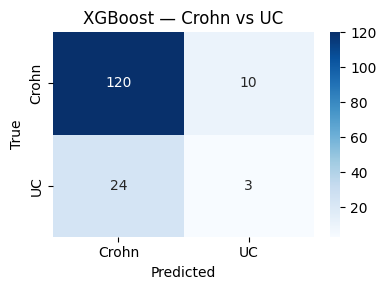

In [53]:
# Step 2: Evaluate XGBoost binary
y_proba_ibd = bst_ibd.predict(dtest_ibd)
y_pred_ibd  = (y_proba_ibd > 0.5).astype(int)

print("XGBoost — Crohn vs UC")
print(classification_report(y_test_ibd, y_pred_ibd, target_names=["Crohn", "UC"]))
print(f"ROC-AUC: {roc_auc_score(y_test_ibd, y_proba_ibd):.4f}")

# Use a separate plot function for binary — don't use plot_cm

def plot_cm_binary(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Crohn", "UC"],
                yticklabels=["Crohn", "UC"],
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cm_binary(y_test_ibd, y_pred_ibd, "XGBoost — Crohn vs UC")

Random Forest — Crohn vs UC
              precision    recall  f1-score   support

       Crohn       0.86      0.89      0.88       130
          UC       0.36      0.30      0.33        27

    accuracy                           0.79       157
   macro avg       0.61      0.59      0.60       157
weighted avg       0.77      0.79      0.78       157



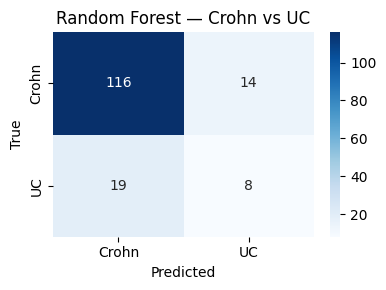

In [54]:
# Step 3: Random Forest binary
rf_ibd = cuRF(
    n_estimators=300,
    max_depth=20,
    max_features=1.0,
    n_bins=16,
    bootstrap=True,
    random_state=42,
)

X_train_ibd_gpu = cudf.DataFrame(X_train_ibd, columns=feature_cols)
X_test_ibd_gpu  = cudf.DataFrame(X_test_ibd,  columns=feature_cols)
y_train_ibd_gpu = cudf.Series(y_train_ibd)
y_test_ibd_gpu  = cudf.Series(y_test_ibd)

rf_ibd.fit(X_train_ibd_gpu, y_train_ibd_gpu)
y_pred_rf_ibd = rf_ibd.predict(X_test_ibd_gpu)

print("Random Forest — Crohn vs UC")
print(classification_report(y_test_ibd, y_pred_rf_ibd.to_numpy(), target_names=["Crohn", "UC"]))

plot_cm_binary(y_test_ibd, y_pred_rf_ibd.to_numpy(), "Random Forest — Crohn vs UC")

Default threshold (0.5): F1 = 0.1500
Optimal threshold (0.36): F1 = 0.4419

Tuned threshold results:
              precision    recall  f1-score   support

       Crohn       0.91      0.69      0.79       130
          UC       0.31      0.67      0.42        27

    accuracy                           0.69       157
   macro avg       0.61      0.68      0.60       157
weighted avg       0.81      0.69      0.72       157



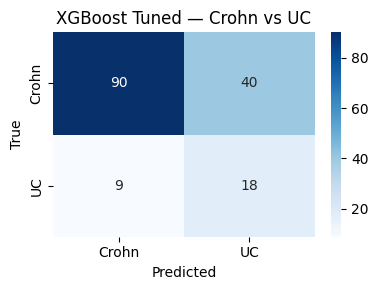

In [55]:
# Step 4: Threshold tuning — find optimal cutoff for UC recall
precisions, recalls, thresholds = precision_recall_curve(y_test_ibd, y_proba_ibd)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh = thresholds[f1_scores.argmax()]

print(f"Default threshold (0.5): F1 = {f1_score(y_test_ibd, (y_proba_ibd > 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}): F1 = {f1_scores.max():.4f}")

# Apply optimal threshold
y_pred_tuned = (y_proba_ibd > best_thresh).astype(int)
print("\nTuned threshold results:")
print(classification_report(y_test_ibd, y_pred_tuned, target_names=["Crohn", "UC"]))
plot_cm_binary(y_test_ibd, y_pred_tuned, "XGBoost Tuned — Crohn vs UC")